In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split

import pandas as pd

# 깃허브에 준비된 데이터를 가져온다.
!git clone https://github.com/taehojo/data.git

#와인 데이터를 불러온다.
df = pd.read_csv('./data/wine.csv', header=None)

# 와인의 속성을 X로, 와인의 분류를 y로 저장한다.
X = df.iloc[:, 0:12]
y = df.iloc[:, 12]

# 학습셋과 테스트셋으로 나눈다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    shuffle=True)

# 모델 구조를 설정한다.
model = Sequential()
model.add(Dense(30, input_dim=12, activation='relu'))
model.add(Dense(12, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# 모델을 컴파일한다.
model.compile(loss='binary_crossentropy', optimizer='adam',
              metrics=['accuracy'])

# 모델을 실행한다.
history = model.fit(X_train, y_train, epochs=2000, batch_size=500,
                    validation_split=0.25)

fatal: destination path 'data' already exists and is not an empty directory.
Epoch 1/2000
8/8 [==============================] - 3s 79ms/step - loss: 6.5084 - accuracy: 0.2407 - val_loss: 4.2395 - val_accuracy: 0.2669
Epoch 2/2000
8/8 [==============================] - 0s 16ms/step - loss: 2.9487 - accuracy: 0.2407 - val_loss: 1.2941 - val_accuracy: 0.2700
Epoch 3/2000
8/8 [==============================] - 0s 14ms/step - loss: 0.8079 - accuracy: 0.6138 - val_loss: 0.5459 - val_accuracy: 0.8938
Epoch 4/2000
8/8 [==============================] - 0s 21ms/step - loss: 0.5068 - accuracy: 0.8907 - val_loss: 0.4634 - val_accuracy: 0.8931
Epoch 5/2000
8/8 [==============================] - 0s 27ms/step - loss: 0.4459 - accuracy: 0.8930 - val_loss: 0.4165 - val_accuracy: 0.8985
Epoch 6/2000
8/8 [==============================] - 0s 22ms/step - loss: 0.4040 - accuracy: 0.9061 - val_loss: 0.3768 - val_accuracy: 0.9154
Epoch 7/2000
8/8 [==============================] - 0s 18ms/step - loss: 0.36

model.fit()은 학습을 진행하면서 매 에포크마다 결과를 출력한다. 일반적으로 loss값이 출력되고 model.compile()에서 metric를 accuracy로 지정하면 accuracy 값이 함께 출력된다. 또한 검증셋을 지정하면 val_loss가 함께 출력된다. 이때 metric를 accuracy로 지정하면 accuracy와 함께 val_accuracy 값도 출력된다,  
  
  
loss: 학습을 통해 구한 예측 값과 실제 값의 차이(=오차)를 의미한다.  
accuracy: 전체 샘플 중에서 정답을 맞춘 샘플이 몇 개인지의 비율(=정확도)를 의미한다.  
  

저장된 history는 model.fit()의 결과를 가진 파이썬 객체로, history.parmas에는 model.fit()의 설정 값들이, history.epoch에는 에포크 정보가 들어 있게 된다. 우리에게 필요한 loss, accuracy, val_loss, val_accuracy는 history.history에 들어있다.

In [2]:
hist_df = pd.DataFrame(history.history)
hist_df

,loss,accuracy,val_loss,val_accuracy
0,6.508415,0.240698,4.239504,0.266923
1,2.948685,0.240698,1.294119,0.270000
2,0.807930,0.613805,0.545865,0.893846
3,0.506822,0.890685,0.463441,0.893077
4,0.445889,0.892995,0.416508,0.898462
...,...,...,...,...
1995,0.013723,0.995894,0.122652,0.986154
1996,0.014085,0.994868,0.120610,0.986923
1997,0.016158,0.995638,0.116396,0.990000
1998,0.020072,0.993585,0.113819,0.987692


실습| 와인의 종류를 예측하기: 그래프 표현

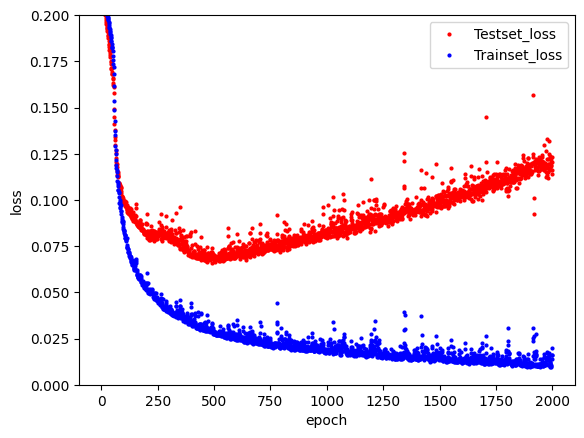

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# y_vloss에 검증셋의 오차를 저장한다.
y_vloss = hist_df['val_loss']

# y_loss에 학습셋의 오차를 저장한다.
y_loss = hist_df['loss']

# x 값을 지정하고 검증셋의 오차를 빨간색으로, 학습셋의 오차를 파란색으로 표시한다.
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, "o", c="red", markersize=2, label="Testset_loss")
plt.plot(x_len, y_loss, "o", c="blue", markersize=2, label="Trainset_loss")

plt.legend(loc='upper right')
plt.ylim(0, 0.2)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()